# Customer Shopping Behavior Analysis

## 1. Importing the libraries
To begin, I loaded the core Python libraries used in this project. They support data manipulation, visualization, standardization, and validation, and they set up the workflow for the analysis that follows.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.plotting.register_matplotlib_converters()
%matplotlib inline


## 2. Loading the data and taking a first look
Here, the dataset is imported and briefly inspected. Viewing the first rows and checking the customer identifier helps confirm that the file was read correctly before moving into deeper inspection.


In [3]:
from pathlib import Path

possible_paths = [
    Path("customer_shopping_behavior.csv"),
    Path("/mnt/data/customer_shopping_behavior.csv"),
    Path("../dados/customer_shopping_behavior.csv")
]

for path in possible_paths:
    if path.exists():
        data_path = path
        break
else:
    raise FileNotFoundError("The file customer_shopping_behavior.csv was not found in the expected paths.")

customer_data = pd.read_csv(data_path)

display(customer_data.head())
print("Dataset shape:", customer_data.shape)
print("Duplicate Customer IDs:", customer_data.duplicated(subset=["Customer ID"]).sum())
display(customer_data.set_index("Customer ID").head())

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


Dataset shape: (5050, 17)
Duplicate Customer IDs: 50


,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
Customer ID,,,,,,,,,,,,,,,,
2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly
521,51,Male,Sunglasses,Accessories,84.0,South Carolina,M,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly
3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly
1687,22,Male,Gloves,Accessories,75.0,Illinois,L,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually
2929,40,Female,Jewelry,Accessories,80.0,Alabama,L,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly


## 3. Understanding the structure of the dataset
At this stage, I review the shape of the dataset, the variable names, data types, unique categorical values, and summary statistics for the numerical fields. This gives a clear picture of what the dataset contains and where potential quality issues may appear.


In [4]:
print("Dataset shape:", customer_data.shape)

print("\nNomes das variáveis:")
display(pd.Index(customer_data.columns))

print("\nTipos de dados:")
display(customer_data.dtypes)

customer_object_columns = customer_data.select_dtypes(include="object").columns
for col in customer_object_columns:
    print(f"\n{col}")
    print(customer_data[col].unique())

customer_numeric = customer_data.select_dtypes(include="number").drop(columns=["Customer ID"], errors="ignore")
display(customer_numeric.describe())


Dataset shape: (5050, 17)

Nomes das variáveis:


Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Previous Purchases', 'Payment Method',
       'Frequency of Purchases'],
      dtype='object')


Tipos de dados:


Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)     float64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Previous Purchases        float64
Payment Method             object
Frequency of Purchases     object
dtype: object


Gender
['Female' 'Male' 'Other']

Item Purchased
['T-shirt' 'Sunglasses' 'Shirt' 'Gloves' 'Jewelry' 'Shorts' 'Hat'
 'Handbag' 'Shoes' 'Coat' 'Laptop' 'Hoodie' 'Phone' 'Jacket' 'Pants'
 'Backpack' 'Socks' 'Jeans' 'Bag' 'Belt' 'Watch' 'Headphones' 'Blouse'
 'Sandals' 'Skirt' 'Sweater' 'Scarf' 'Sneakers' 'Boots' 'Dress']

Category
['Clothing' 'Accessories' 'Outerwear' 'Electronics' 'Footwear']

Location
['California' 'South Carolina' 'Montana' 'Illinois' 'Alabama' 'Wisconsin'
 'Tennessee' 'Florida' 'Kentucky' 'Phoenix' 'Pennsylvania' 'Los Angeles'
 'Vermont' 'North Dakota' 'Ohio' 'Colorado' 'Maine' 'Massachusetts'
 'Arkansas' 'New York' 'Indiana' 'Maryland' 'New Mexico' 'Michigan'
 'Connecticut' 'Louisiana' 'Minnesota' 'Oregon' 'Kansas' 'Houston'
 'South Dakota' 'New Jersey' 'New Hampshire' 'North Carolina' 'Hawaii'
 'Nebraska' 'Virginia' 'Chicago' 'Iowa' 'Oklahoma' 'Delaware' 'Utah'
 'Missouri' 'Alaska' 'Mississippi' 'Arizona' 'Texas' 'West Virginia'
 'Washington' 'Nevada' 'Rhode Island

,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,5050.000000,4494.000000,4449.000000,4502.000000
mean,44.150495,144.765236,3.668195,25.221901
std,15.282328,275.590101,0.865357,14.521635
min,18.000000,10.120000,1.000000,0.000000
25%,31.000000,41.000000,3.000000,13.000000
50%,44.000000,65.000000,3.700000,25.000000
75%,57.000000,89.000000,4.400000,38.000000
max,70.000000,1499.760000,5.000000,50.000000


## 4. Checking missing values
Before applying any treatment, I inspect how many missing values are present in each variable. This step helps determine which fields require imputation, recoding, or a more careful interpretation.


In [5]:
customer_data.isnull().sum().sort_values(ascending=False)


Review Rating             601
Purchase Amount (USD)     556
Previous Purchases        548
Size                      370
Customer ID                 0
Category                    0
Item Purchased              0
Age                         0
Gender                      0
Color                       0
Location                    0
Subscription Status         0
Season                      0
Shipping Type               0
Discount Applied            0
Payment Method              0
Frequency of Purchases      0
dtype: int64

## 5. Looking at the initial distributions
These first visualizations show how the main numerical and categorical variables are distributed before cleaning. They help reveal skewness, concentration, unusual patterns, and early signs of inconsistency.


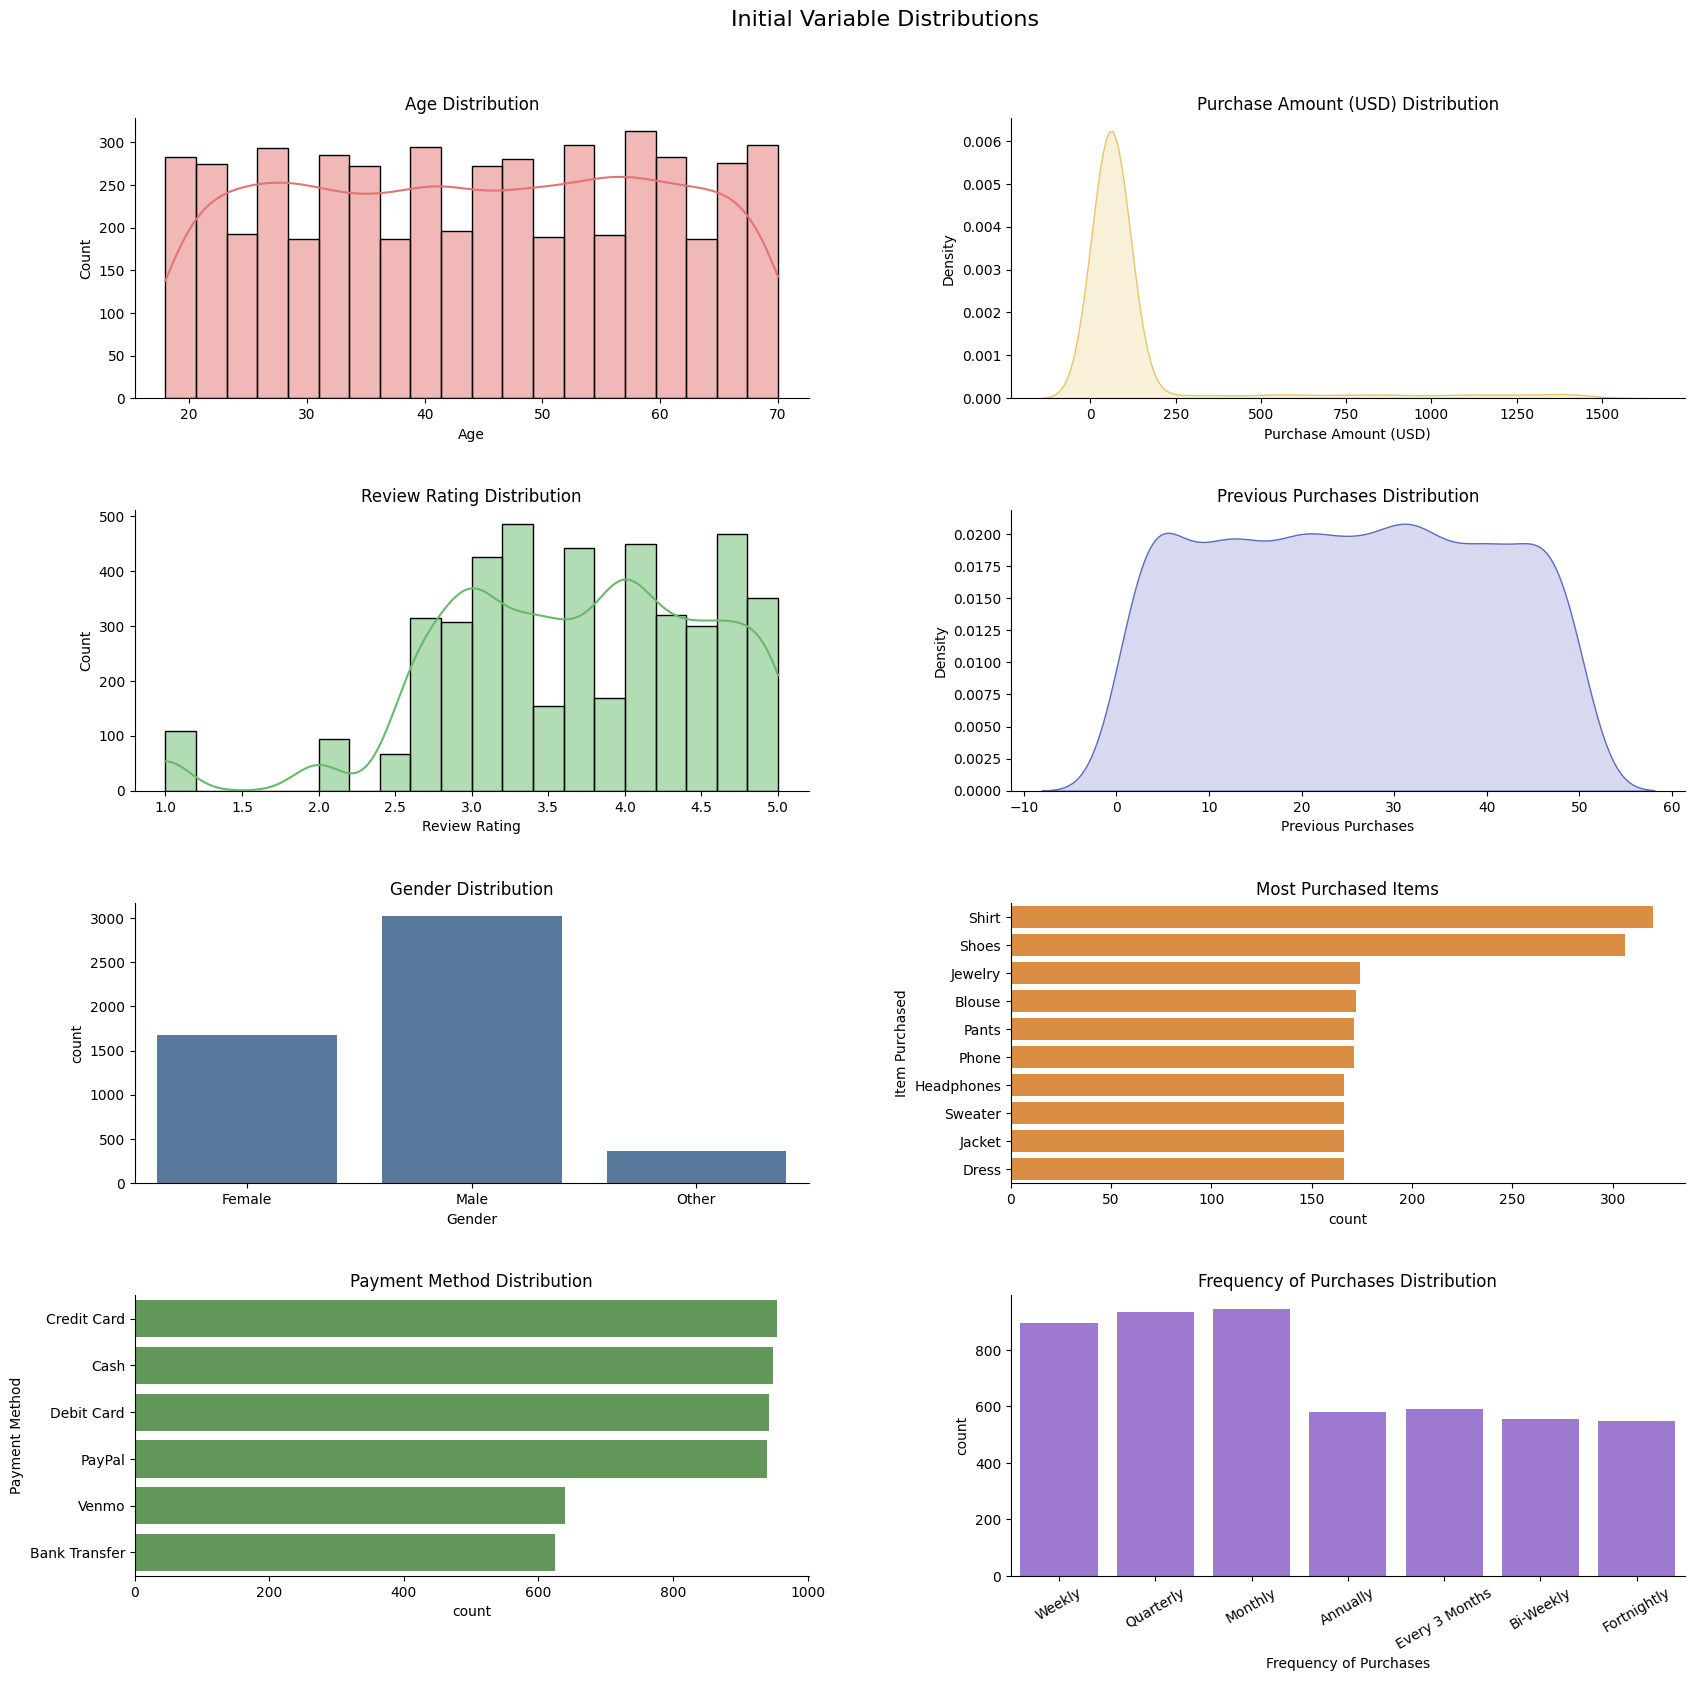

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(20, 18))
fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.92)
axes = axes.flatten()
fig.suptitle("Initial Variable Distributions", fontsize=16)

sns.histplot(data=customer_data, x="Age", bins=20, kde=True, color="#E57373", ax=axes[0])
axes[0].set_title("Age Distribution")

sns.kdeplot(data=customer_data["Purchase Amount (USD)"], fill=True, color="#E9C46A", ax=axes[1])
axes[1].set_title("Purchase Amount (USD) Distribution")

sns.histplot(data=customer_data, x="Review Rating", bins=20, kde=True, color="#66BB6A", ax=axes[2])
axes[2].set_title("Review Rating Distribution")

sns.kdeplot(data=customer_data["Previous Purchases"], fill=True, color="#5C6BC0", ax=axes[3])
axes[3].set_title("Previous Purchases Distribution")

sns.countplot(data=customer_data, x="Gender", ax=axes[4], color="#4E79A7")
axes[4].set_title("Gender Distribution")

item_order = customer_data["Item Purchased"].value_counts().head(10).index
sns.countplot(data=customer_data, order=item_order, y="Item Purchased", ax=axes[5], color="#F28E2B")
axes[5].set_title("Most Purchased Items")

payment_order = customer_data["Payment Method"].value_counts().index
sns.countplot(data=customer_data, y="Payment Method", order=payment_order, ax=axes[6], color="#59A14F")
axes[6].set_title("Payment Method Distribution")

sns.countplot(data=customer_data, x="Frequency of Purchases", ax=axes[7], color="#9C6ADE")
axes[7].set_title("Frequency of Purchases Distribution")
axes[7].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()


## 6. Initial cross-variable exploration
Next, I explore how key variables relate to one another. This early comparison helps uncover possible behavioral patterns as well as structural problems that should be addressed during data cleaning.


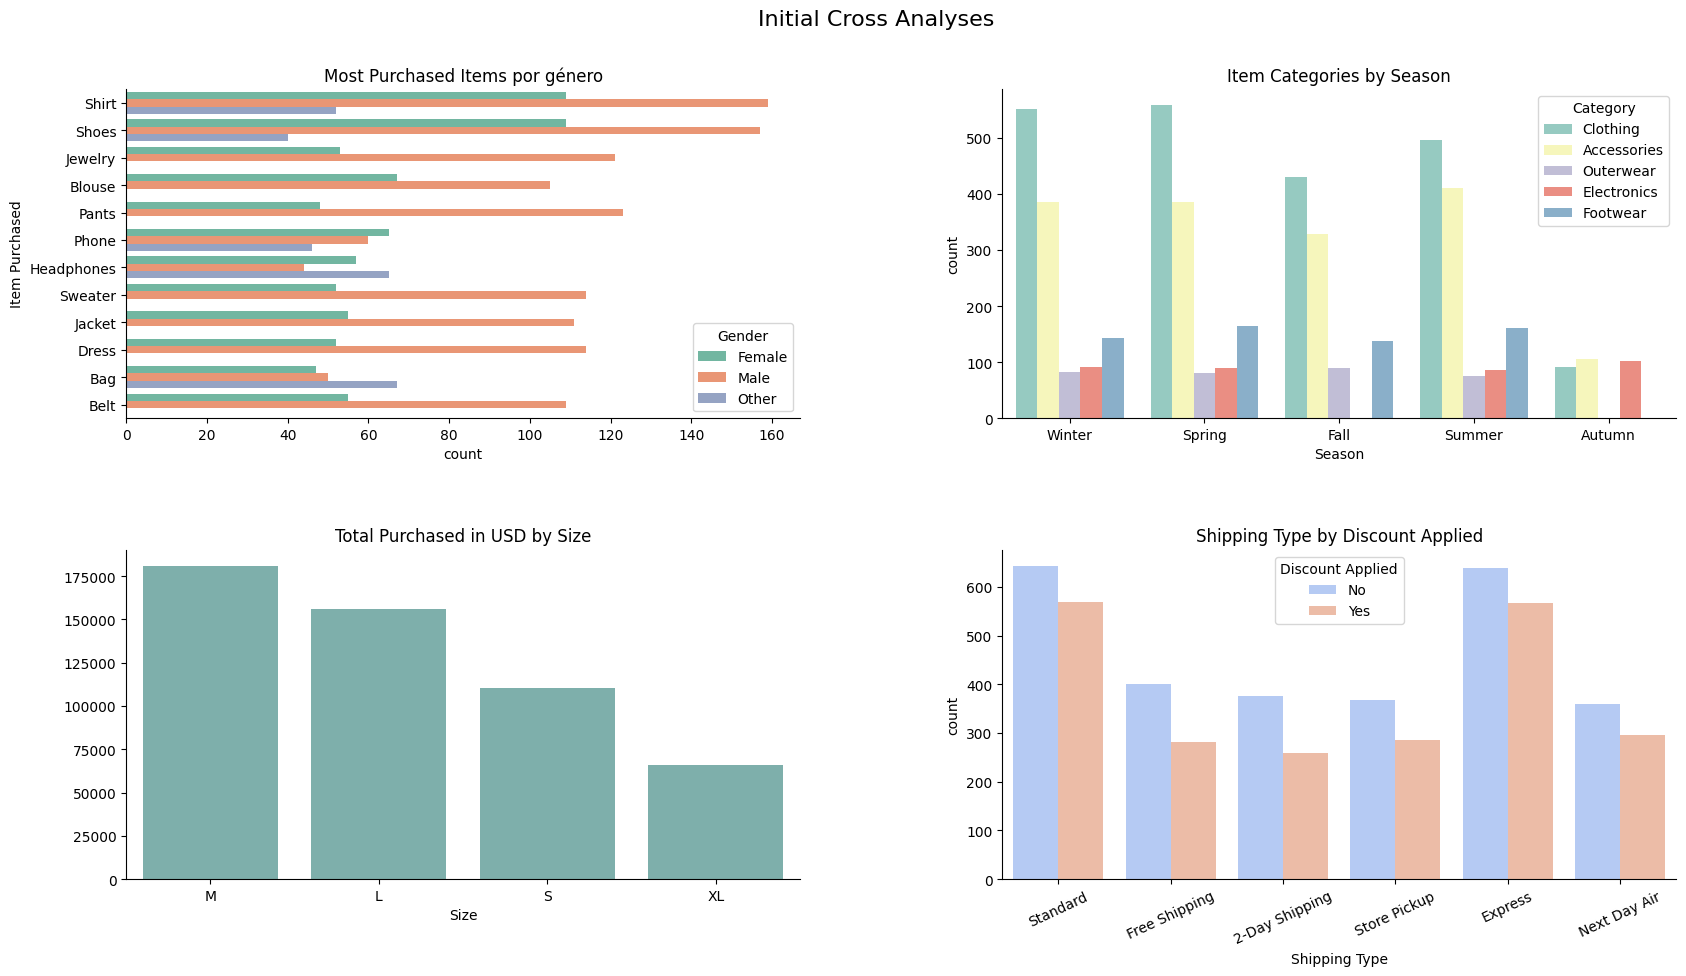

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3, top=0.9)
axes = axes.flatten()
fig.suptitle("Initial Cross Analyses", fontsize=16)

item_order = customer_data["Item Purchased"].value_counts().head(12).index
sns.countplot(
    data=customer_data,
    order=item_order,
    y="Item Purchased",
    hue="Gender",
    ax=axes[0],
    palette="Set2"
)
axes[0].set_title("Most Purchased Items por género")

sns.countplot(
    data=customer_data,
    x="Season",
    hue="Category",
    ax=axes[1],
    palette="Set3"
)
axes[1].set_title("Item Categories by Season")

totais_size = customer_data.groupby("Size")["Purchase Amount (USD)"].sum().sort_values(ascending=False)
sns.barplot(x=totais_size.index, y=totais_size.values, ax=axes[2], color="#76B7B2")
axes[2].set_title("Total Purchased in USD by Size")

sns.countplot(
    data=customer_data,
    x="Shipping Type",
    hue="Discount Applied",
    ax=axes[3],
    palette="coolwarm"
)
axes[3].set_title("Shipping Type by Discount Applied")
axes[3].tick_params(axis="x", rotation=25)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.show()

## 7. Creating a working copy
Rather than editing the original dataset directly, I create a separate working copy. This keeps the raw data untouched and makes the cleaning process easier to track and reproduce.


In [8]:
custumer_data_copy = customer_data.copy()
custumer_data_copy.isnull().sum().sort_values(ascending=False)


Review Rating             601
Purchase Amount (USD)     556
Previous Purchases        548
Size                      370
Customer ID                 0
Category                    0
Item Purchased              0
Age                         0
Gender                      0
Color                       0
Location                    0
Subscription Status         0
Season                      0
Shipping Type               0
Discount Applied            0
Payment Method              0
Frequency of Purchases      0
dtype: int64

## 8. Duplicate treatment
This section checks for fully duplicated rows in the working dataset and removes exact repetitions. Doing so prevents identical records from being counted more than once and helps keep descriptive results more reliable.


In [9]:
duplicate_count = custumer_data_copy.duplicated().sum()
duplicated_rows_preview = custumer_data_copy[custumer_data_copy.duplicated(keep=False)]

print("Number of duplicate rows before treatment:", duplicate_count)
display(duplicated_rows_preview.head())

custumer_data_copy = custumer_data_copy.drop_duplicates().reset_index(drop=True)

print("Number of duplicate rows after treatment:", custumer_data_copy.duplicated().sum())
print("New dataset shape:", custumer_data_copy.shape)

Number of duplicate rows before treatment: 50


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
176,2834,43,Female,Jeans,Clothing,56.0,Arkansas,M,Teal,Fall,3.3,No,Free Shipping,No,19.0,Cash,Monthly
271,1698,36,Male,Shirt,Clothing,87.0,South Carolina,L,Lavender,Fall,3.5,No,Next Day Air,No,48.0,Credit Card,Every 3 Months
483,974,60,Male,Jacket,Outerwear,75.0,Colorado,M,Teal,Fall,3.5,Yes,2-Day Shipping,Yes,30.0,Bank Transfer,Quarterly
667,3507,18,Female,Shirt,Clothing,57.0,Illinois,L,Olive,Winter,3.7,No,2-Day Shipping,No,12.0,Cash,Fortnightly
707,2069,70,Male,Jewelry,Accessories,81.0,Vermont,XL,Black,Summer,3.9,No,Store Pickup,No,44.0,Venmo,Monthly


Number of duplicate rows after treatment: 0
New dataset shape: (5000, 17)


## 9. Imputing `Purchase Amount (USD)`
Missing values in `Purchase Amount (USD)` are filled using a hierarchical median-by-group strategy. The method starts with more specific groupings and gradually moves to broader ones, finishing with the overall median only when needed.


In [10]:
print("NaN before:", custumer_data_copy["Purchase Amount (USD)"].isna().sum())

custumer_data_copy["Purchase Amount (USD)"] = custumer_data_copy["Purchase Amount (USD)"].fillna(
    custumer_data_copy.groupby(
        ["Category", "Item Purchased", "Season", "Discount Applied"]
    )["Purchase Amount (USD)"].transform("median")
)

custumer_data_copy["Purchase Amount (USD)"] = custumer_data_copy["Purchase Amount (USD)"].fillna(
    custumer_data_copy.groupby(
        ["Category", "Item Purchased", "Season"]
    )["Purchase Amount (USD)"].transform("median")
)

custumer_data_copy["Purchase Amount (USD)"] = custumer_data_copy["Purchase Amount (USD)"].fillna(
    custumer_data_copy.groupby(
        ["Category", "Season"]
    )["Purchase Amount (USD)"].transform("median")
)

custumer_data_copy["Purchase Amount (USD)"] = custumer_data_copy["Purchase Amount (USD)"].fillna(
    custumer_data_copy["Purchase Amount (USD)"].median()
)

print("NaN after:", custumer_data_copy["Purchase Amount (USD)"].isna().sum())


NaN before: 556
NaN after: 0


## 10. Correcting `Size` where it does not apply
The `Size` field uses clothing-style labels such as `S`, `M`, `L`, and `XL`. Since those values do not make sense for categories like `Accessories`, `Electronics`, and `Footwear`, these cases are recoded as `Not Applicable` to improve semantic consistency.


In [11]:
size_not_applicable_mask = custumer_data_copy["Category"].isin(["Accessories", "Electronics", "Footwear"])
custumer_data_copy.loc[size_not_applicable_mask, "Size"] = "Not Applicable"

pd.crosstab(custumer_data_copy["Category"], custumer_data_copy["Size"])


Size,L,M,Not Applicable,S,XL
Category,,,,,
Accessories,0,0,1598,0,0
Clothing,561,872,0,376,300
Electronics,0,0,370,0,0
Footwear,0,0,599,0,0
Outerwear,93,148,0,56,27


## 11. Handling `Review Rating` more carefully
Instead of forcing an imputed value into `Review Rating`, I keep the missing cases and add an indicator showing whether a customer left a review. This is more appropriate because a missing rating may reflect the absence of feedback rather than a data error.


In [12]:
custumer_data_copy["Has Review"] = custumer_data_copy["Review Rating"].notna().map({True: "Yes", False: "No"})

print(custumer_data_copy["Has Review"].value_counts())
print(custumer_data_copy["Review Rating"].isna().sum())


Has Review
Yes    4401
No      599
Name: count, dtype: int64
599


## 12. Imputing `Previous Purchases`
The missing values in `Previous Purchases` are treated with the same hierarchical median approach used for purchase amount, using groups built from `Category`, `Item Purchased`, `Season`, and `Frequency of Purchases`. The median is preferred here because monetary variables often contain skewness and extreme values.


In [13]:
print("NaN before:", custumer_data_copy["Previous Purchases"].isna().sum())

custumer_data_copy["Previous Purchases"] = custumer_data_copy["Previous Purchases"].fillna(
    custumer_data_copy.groupby(
        ["Category", "Item Purchased", "Season", "Frequency of Purchases"]
    )["Previous Purchases"].transform("median")
)

custumer_data_copy["Previous Purchases"] = custumer_data_copy["Previous Purchases"].fillna(
    custumer_data_copy.groupby(
        ["Category", "Season", "Frequency of Purchases"]
    )["Previous Purchases"].transform("median")
)

custumer_data_copy["Previous Purchases"] = custumer_data_copy["Previous Purchases"].fillna(
    custumer_data_copy.groupby(
        ["Category", "Frequency of Purchases"]
    )["Previous Purchases"].transform("median")
)

custumer_data_copy["Previous Purchases"] = custumer_data_copy["Previous Purchases"].fillna(
    custumer_data_copy["Previous Purchases"].median()
)

print("NaN after:", custumer_data_copy["Previous Purchases"].isna().sum())


NaN before: 548
NaN after: 0


## 13. Reviewing and recoding `Category`
Here I compare `Item Purchased` with `Category` to identify mismatches. Once the inconsistencies are counted, categories are reassigned according to a business rule based on the purchased item, making the product classification more coherent.


In [14]:
pd.crosstab(custumer_data_copy["Item Purchased"], custumer_data_copy["Category"])


Category,Accessories,Clothing,Electronics,Footwear,Outerwear
Item Purchased,,,,,
Backpack,143,0,0,0,0
Bag,55,56,53,0,0
Belt,161,0,0,0,0
Blouse,0,171,0,0,0
Boots,0,0,0,144,0
Coat,0,0,0,0,161
Dress,0,166,0,0,0
Gloves,140,0,0,0,0
Handbag,153,0,0,0,0


In [15]:
category_map = {
    "Backpack": "Accessories",
    "Bag": "Accessories",
    "Belt": "Accessories",
    "Blouse": "Clothing",
    "Boots": "Footwear",
    "Coat": "Outerwear",
    "Dress": "Clothing",
    "Gloves": "Accessories",
    "Handbag": "Accessories",
    "Hat": "Accessories",
    "Headphones": "Electronics",
    "Hoodie": "Clothing",
    "Jacket": "Outerwear",
    "Jeans": "Clothing",
    "Jewelry": "Accessories",
    "Laptop": "Electronics",
    "Pants": "Clothing",
    "Phone": "Electronics",
    "Sandals": "Footwear",
    "Scarf": "Accessories",
    "Shirt": "Clothing",
    "Shoes": "Footwear",
    "Shorts": "Clothing",
    "Skirt": "Clothing",
    "Sneakers": "Footwear",
    "Socks": "Clothing",
    "Sunglasses": "Accessories",
    "Sweater": "Clothing",
    "T-shirt": "Clothing",
    "Watch": "Accessories"
}

custumer_data_copy["Category_expected"] = custumer_data_copy["Item Purchased"].map(category_map)
incoerentes = custumer_data_copy[custumer_data_copy["Category"] != custumer_data_copy["Category_expected"]]

display(incoerentes[["Item Purchased", "Category", "Category_expected"]].head())
print("Total inconsistencies:", incoerentes.shape[0])

custumer_data_copy["Category"] = custumer_data_copy["Category_expected"]
custumer_data_copy = custumer_data_copy.drop(columns=["Category_expected"])


,Item Purchased,Category,Category_expected
10,Shoes,Clothing,Footwear
24,Phone,Clothing,Electronics
26,Phone,Accessories,Electronics
35,Bag,Clothing,Accessories
38,Watch,Electronics,Accessories


Total inconsistencies: 799


## 14. Standardizing `Location`
The `Location` field mixes cities and states, which creates an inconsistent geographic level of analysis. To solve this, city names are replaced with their corresponding states so that the variable represents a single territorial scale.


In [16]:
location_map = {
    "Phoenix": "Arizona",
    "Los Angeles": "California",
    "Houston": "Texas",
    "Chicago": "Illinois"
}

custumer_data_copy["Location"] = custumer_data_copy["Location"].replace(location_map)
sorted(custumer_data_copy["Location"].unique())


['Alabama',
 'Alaska',
 'Arizona',
 'Arkansas',
 'California',
 'Colorado',
 'Connecticut',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Idaho',
 'Illinois',
 'Indiana',
 'Iowa',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Maine',
 'Maryland',
 'Massachusetts',
 'Michigan',
 'Minnesota',
 'Mississippi',
 'Missouri',
 'Montana',
 'Nebraska',
 'Nevada',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'New York',
 'North Carolina',
 'North Dakota',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'South Carolina',
 'South Dakota',
 'Tennessee',
 'Texas',
 'Utah',
 'Vermont',
 'Virginia',
 'Washington',
 'West Virginia',
 'Wisconsin',
 'Wyoming']

## 15. Standardizing `Frequency of Purchases`
Some purchase-frequency labels carry the same meaning but appear under different names. In this step, equivalent labels are harmonized so that later comparisons are clearer and more consistent.


In [17]:
custumer_data_copy["Frequency of Purchases"] = custumer_data_copy["Frequency of Purchases"].replace({
    "Every 3 Months": "Quarterly",
    "Fortnightly": "Bi-Weekly"
})

sorted(custumer_data_copy["Frequency of Purchases"].unique())


['Annually', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Weekly']

## 16. Final conformity check
Once the treatments are complete, I run a final validation step. This includes checking remaining missing values, reviewing standardized categories, and previewing the cleaned dataset before the final exploratory analysis.


In [18]:
display(custumer_data_copy.isnull().sum().sort_values(ascending=False))
print("Final duplicates:", custumer_data_copy.duplicated().sum())
print("Final Frequency of Purchases categories:", sorted(custumer_data_copy["Frequency of Purchases"].unique()))
print("Final standardized locations:", sorted(custumer_data_copy["Location"].unique()))
display(pd.crosstab(custumer_data_copy["Category"], custumer_data_copy["Size"]))
display(custumer_data_copy.head())

Review Rating             599
Customer ID                 0
Age                         0
Gender                      0
Category                    0
Item Purchased              0
Location                    0
Size                        0
Color                       0
Purchase Amount (USD)       0
Season                      0
Subscription Status         0
Shipping Type               0
Discount Applied            0
Previous Purchases          0
Payment Method              0
Frequency of Purchases      0
Has Review                  0
dtype: int64

Final duplicates: 0
Final Frequency of Purchases categories: ['Annually', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Weekly']
Final standardized locations: ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']


Size,L,M,Not Applicable,S,XL
Category,,,,,
Accessories,17,35,1452,19,38
Clothing,496,790,92,302,203
Electronics,36,35,321,44,44
Footwear,12,12,702,11,15
Outerwear,93,148,0,56,27


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,Has Review
0,2701,22,Female,T-shirt,Clothing,68.0,California,XL,Olive,Winter,3.2,No,Standard,No,36.0,Cash,Weekly,Yes
1,521,51,Male,Sunglasses,Accessories,84.0,South Carolina,Not Applicable,White,Spring,3.9,Yes,Free Shipping,Yes,20.0,Debit Card,Quarterly,Yes
2,3157,18,Female,Shirt,Clothing,50.0,Montana,M,Black,Winter,3.1,No,2-Day Shipping,No,18.0,Cash,Monthly,Yes
3,1687,22,Male,Gloves,Accessories,75.0,Illinois,Not Applicable,Red,Fall,4.2,No,Store Pickup,No,25.0,Cash,Annually,Yes
4,2929,40,Female,Jewelry,Accessories,80.0,Alabama,Not Applicable,Yellow,Spring,3.6,No,Store Pickup,No,17.0,Credit Card,Weekly,Yes


### Data quality and conformity insights

After the cleaning stage, the dataset is in much better shape. The only remaining missing values are in `Review Rating` (**599 cases**), and those were intentionally preserved because they may indicate that a customer simply did not leave a review.

The main monetary variables were fully completed, product categories now align with the purchased item, `Location` has been standardized to the state level, and redundant purchase-frequency labels were removed. The duplicate check also found **50 exact repeated rows**, which were removed in this version of the workflow.

One limitation still remains: the `Season` variable includes both **`Fall`** and **`Autumn`**, even though they describe the same season. That inconsistency should be addressed in a future refinement.


## 17. General profile of customers and purchases
This section provides a broad snapshot of the cleaned dataset. The plots summarize age, purchase amount, gender, and subscription status, giving a quick sense of who the customers are and how purchases are distributed overall.


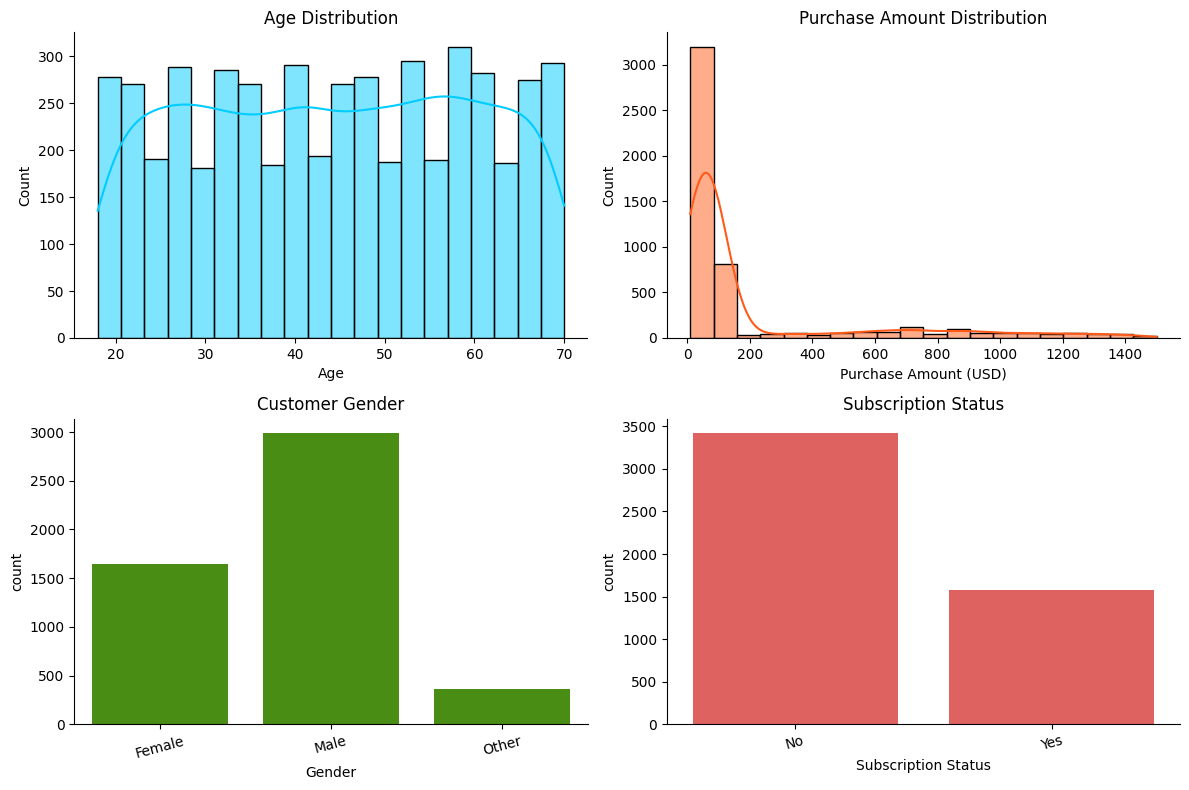

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

sns.histplot(data=custumer_data_copy, x='Age', bins=20, kde=True, ax=axes[0], color="#00CCFF")
axes[0].set_title('Age Distribution')

sns.histplot(data=custumer_data_copy, x='Purchase Amount (USD)', bins=20, kde=True, ax=axes[1], color="#FF5A19")
axes[1].set_title('Purchase Amount Distribution')

sns.countplot(data=custumer_data_copy, x='Gender', ax=axes[2], color="#46A100")
axes[2].set_title('Customer Gender')
axes[2].tick_params(axis='x', rotation=15)

sns.countplot(data=custumer_data_copy, x='Subscription Status', ax=axes[3], color="#F34E4B")
axes[3].set_title('Subscription Status')
axes[3].tick_params(axis='x', rotation=15)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### General profile insights

The customer base is centered around middle adulthood, with both the **mean and median age equal to 44**. Gender distribution is led by male customers (**59.8%**), followed by female customers (**33.1%**) and a smaller `Other` category (**7.2%**).

Spending is far from evenly distributed. Although the average `Purchase Amount (USD)` is **USD 207.68**, the median is just **USD 70**, which points to a strongly right-skewed distribution driven by a smaller number of expensive purchases. Most records also come from **non-subscribers (68.6%)**, which creates a useful contrast for later comparisons.


## 18. Purchase behavior
Now the focus shifts to how customers buy. The next set of visuals compares purchase volume, purchase amount, seasonality, and buying frequency to highlight differences across product segments and shopping patterns.


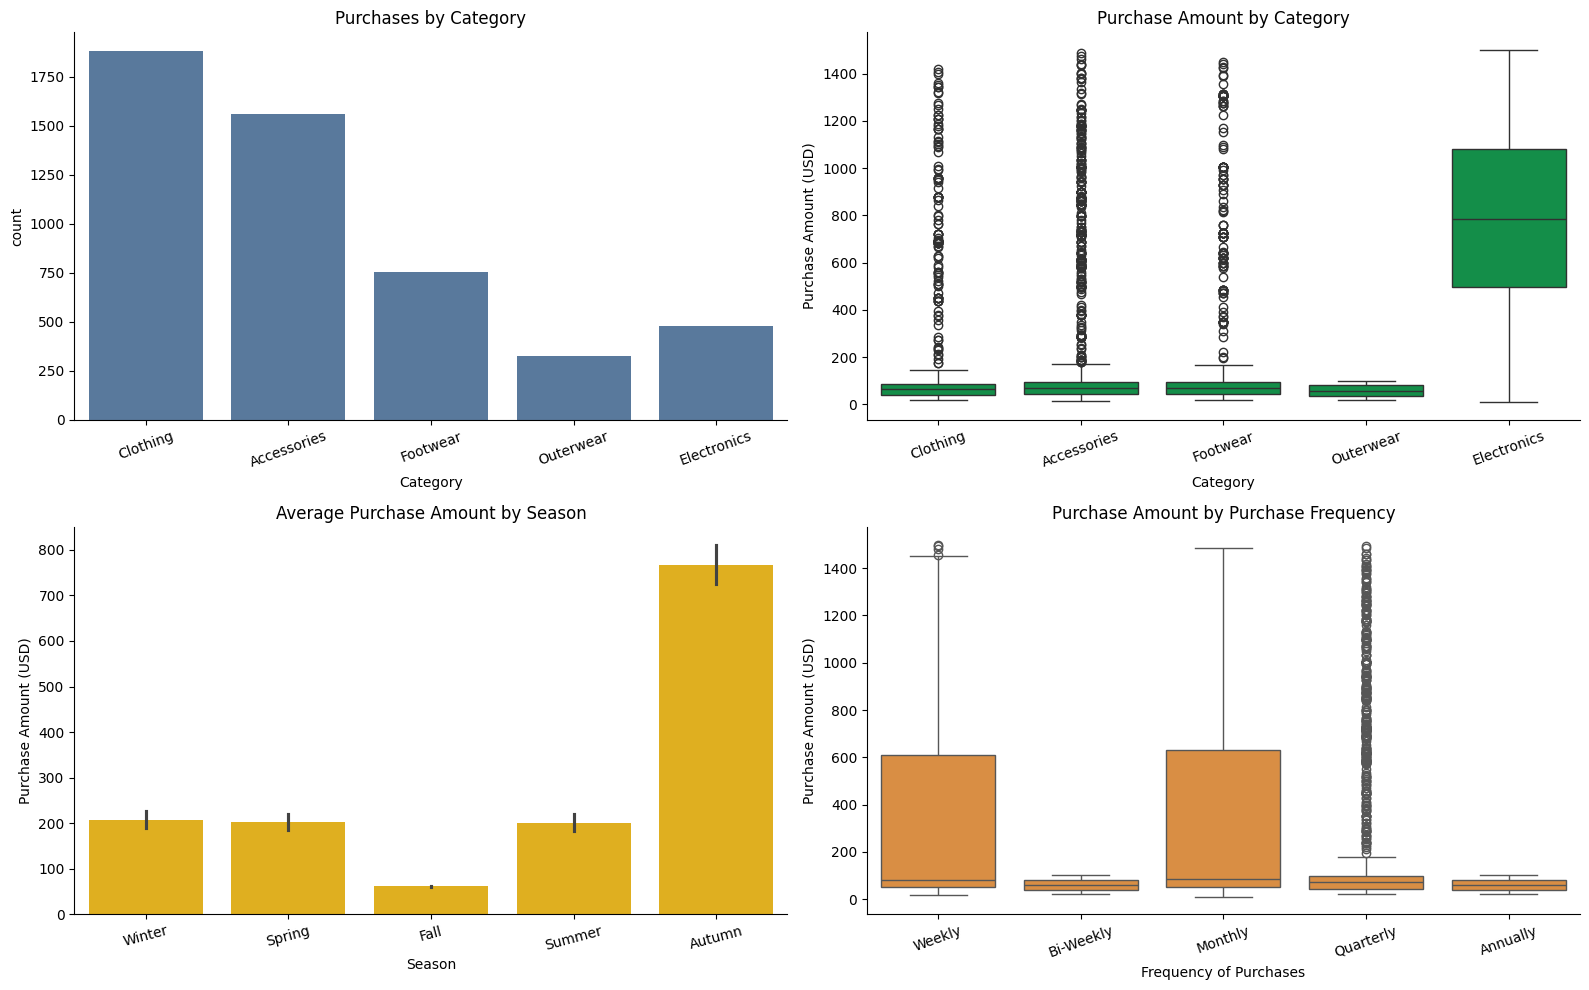

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

sns.countplot(data=custumer_data_copy, x='Category', color="#4E79A7", ax=axes[0])
axes[0].set_title('Purchases by Category')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=custumer_data_copy, x='Category', y='Purchase Amount (USD)', color="#00A246", ax=axes[1])
axes[1].set_title('Purchase Amount by Category')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=custumer_data_copy, x='Season', y='Purchase Amount (USD)', estimator=np.mean, color="#FFBF00", ax=axes[2])
axes[2].set_title('Average Purchase Amount by Season')
axes[2].tick_params(axis='x', rotation=15)

order = ['Weekly', 'Bi-Weekly', 'Monthly', 'Quarterly', 'Annually']
sns.boxplot(
    data=custumer_data_copy,
    x='Frequency of Purchases',
    y='Purchase Amount (USD)',
    order=order,
    color="#F28E2B",
    ax=axes[3]
)
axes[3].set_title('Purchase Amount by Purchase Frequency')
axes[3].tick_params(axis='x', rotation=20)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Purchase behavior insights

In terms of volume, **`Clothing`** dominates the dataset (**37.7%** of records), followed by **`Accessories`** (**31.2%**). Financially, however, the picture changes: **`Electronics`** stands out by a wide margin, with an **average purchase amount of USD 774.69** and a median of **USD 784.88**. This means the most common category is not necessarily the most valuable one.

Seasonal results are less stable. **`Autumn`** shows the highest mean purchase amount (**USD 767.12**), but that pattern should be interpreted with caution because the dataset still treats `Autumn` and `Fall` as separate labels. Looking at shopping rhythm, customers who buy **monthly** or **weekly** tend to post the highest average values, suggesting that more frequent buyers also generate stronger revenue.


## 19. Loyalty, reviews, and repeat behavior
This part looks at customer engagement from several angles: whether customers leave reviews, whether subscribers spend differently, how previous purchase history relates to the current basket, and how ratings vary by category.


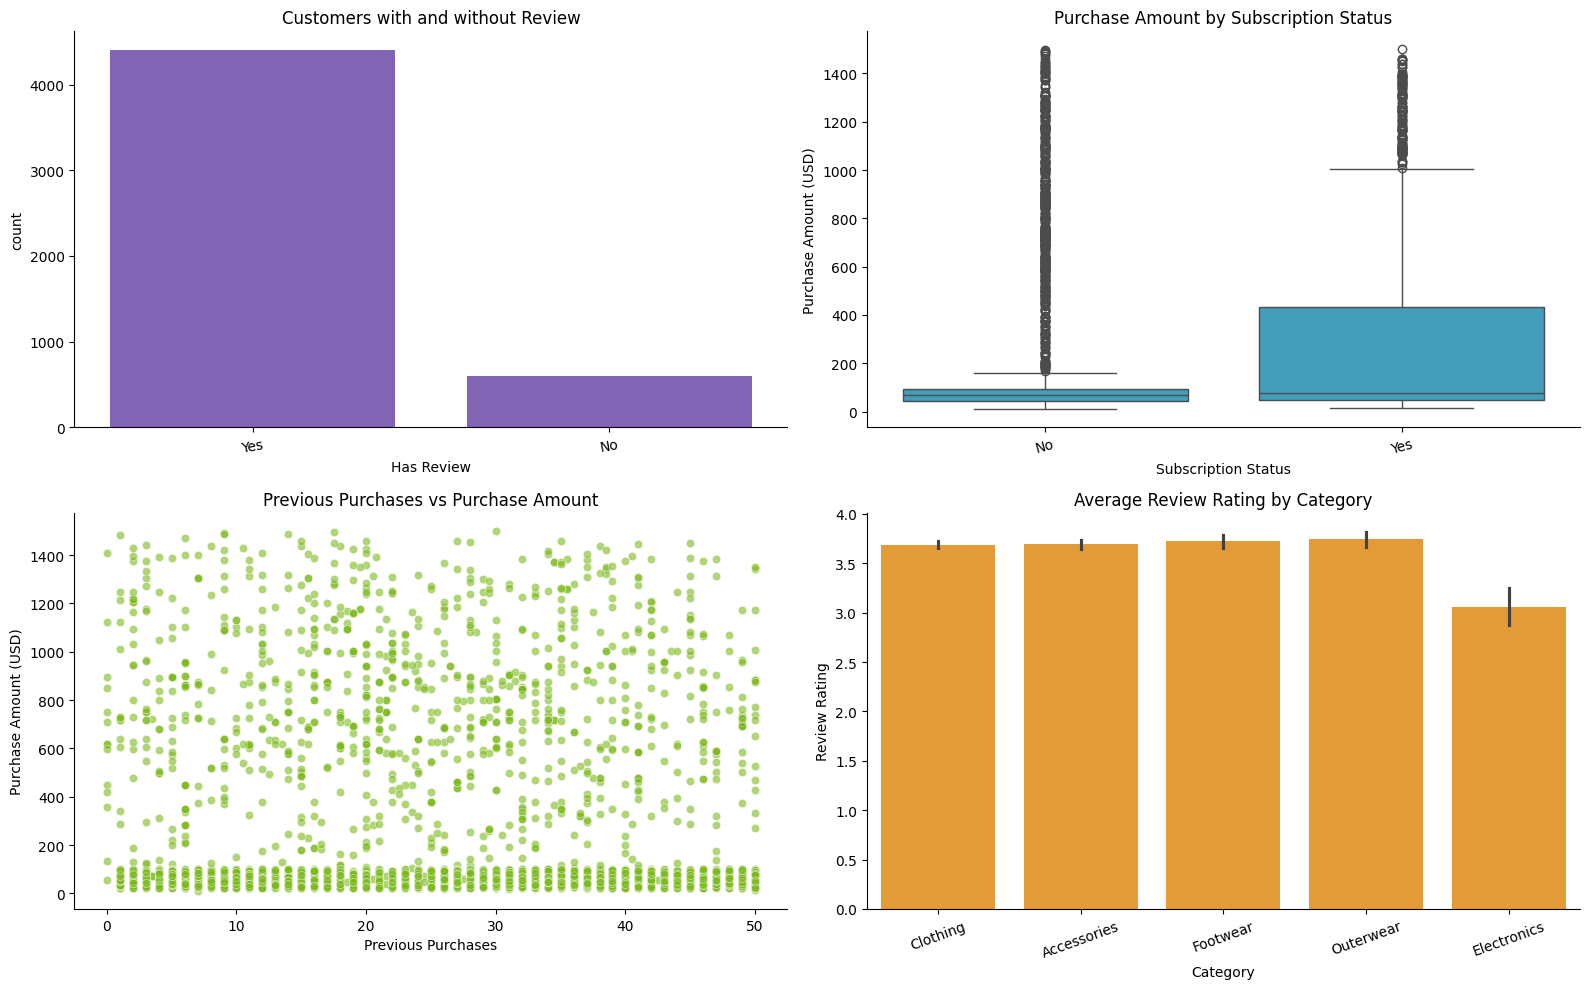

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

sns.countplot(data=custumer_data_copy, x='Has Review', color="#7E57C2", ax=axes[0])
axes[0].set_title('Customers with and without Review')
axes[0].tick_params(axis='x', rotation=10)

sns.boxplot(data=custumer_data_copy, x='Subscription Status', y='Purchase Amount (USD)', color="#2EA9CE", ax=axes[1])
axes[1].set_title('Purchase Amount by Subscription Status')
axes[1].tick_params(axis='x', rotation=15)

sns.scatterplot(data=custumer_data_copy, x='Previous Purchases', y='Purchase Amount (USD)', color="#7CB91A", alpha=0.6, ax=axes[2])
axes[2].set_title('Previous Purchases vs Purchase Amount')

sns.barplot(data=custumer_data_copy, x='Category', y='Review Rating', estimator=np.mean, color="#FF9F1C", ax=axes[3])
axes[3].set_title('Average Review Rating by Category')
axes[3].tick_params(axis='x', rotation=20)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Loyalty, review, and recurrence insights

Most records include a review: **88.1%** of customers provided a `Review Rating`, while **11.9%** did not. Among product groups, **`Outerwear`** receives the highest average rating (**3.74**), whereas **`Electronics`** records the lowest (**3.06**), which may suggest a more demanding customer experience in that segment.

Subscription status appears to matter financially. Customers with an **active subscription** spend substantially more on average (**USD 282.97**) than those without one (**USD 173.15**). By contrast, the linear relationship between `Previous Purchases` and the current `Purchase Amount (USD)` is almost nonexistent (**r = -0.02**), so past monetary history alone does not explain current spending very well.


## 20. Payment methods and logistics
The final operational view looks at how customers pay and how orders are shipped. Besides showing the most common options, it also compares the average purchase amount across payment and shipping categories.


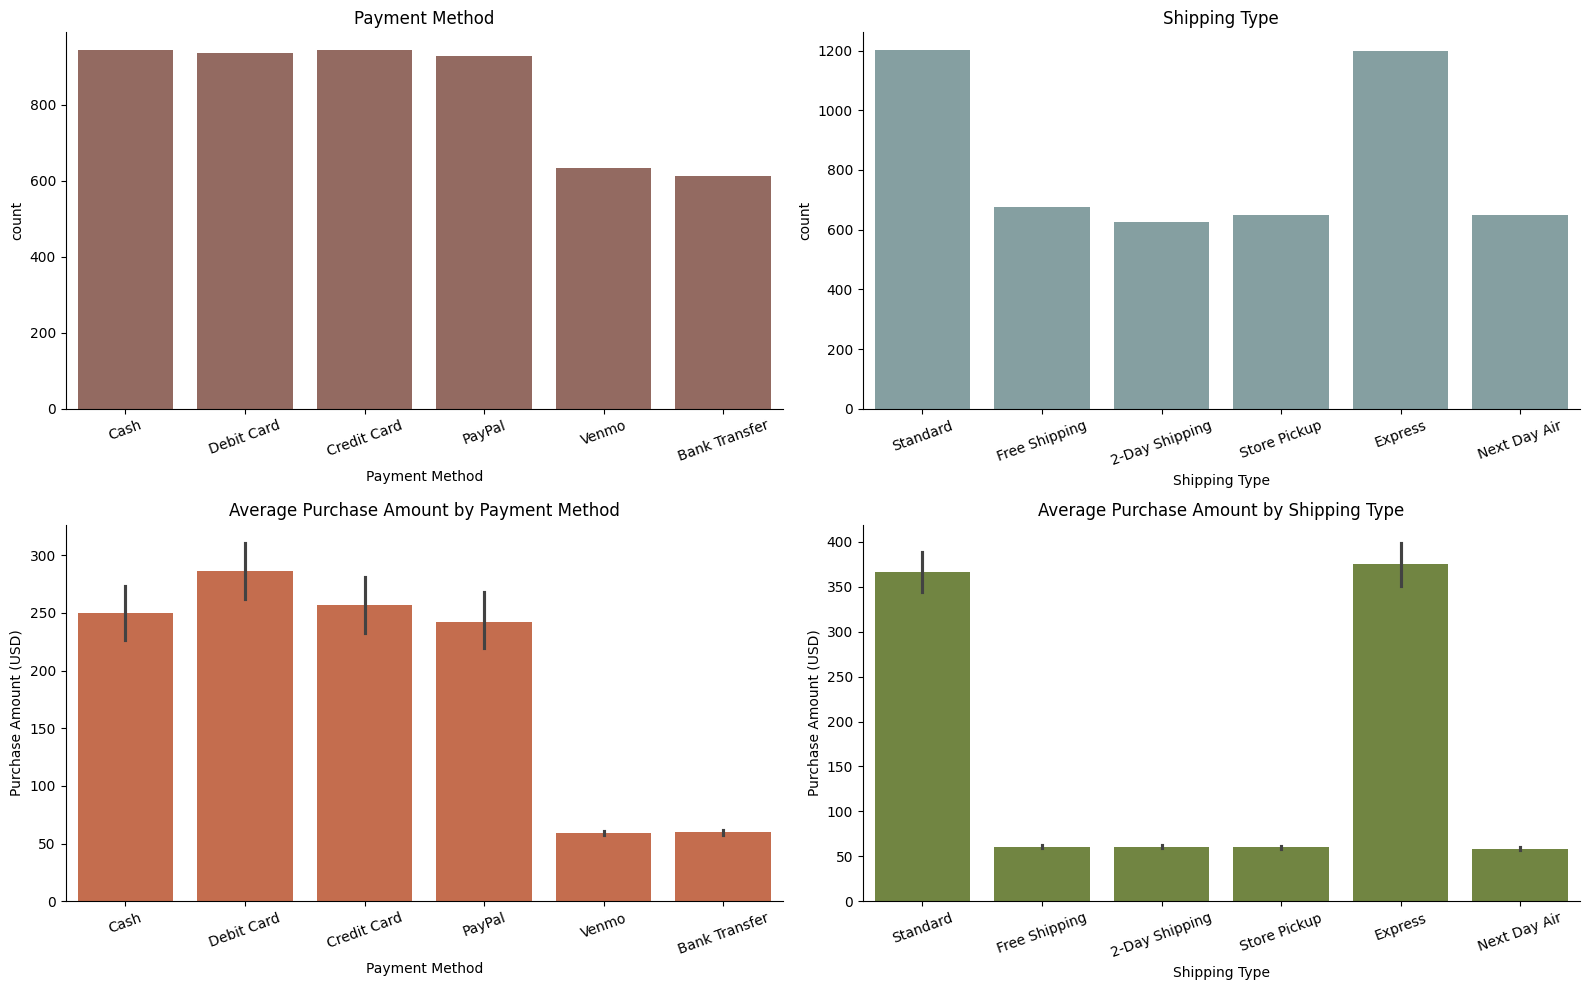

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

sns.countplot(data=custumer_data_copy, x='Payment Method', color="#9B6459", ax=axes[0])
axes[0].set_title('Payment Method')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=custumer_data_copy, x='Shipping Type', color="#81A3A5", ax=axes[1])
axes[1].set_title('Shipping Type')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=custumer_data_copy, x='Payment Method', y='Purchase Amount (USD)', estimator=np.mean, color="#D8643A", ax=axes[2])
axes[2].set_title('Average Purchase Amount by Payment Method')
axes[2].tick_params(axis='x', rotation=20)

sns.barplot(data=custumer_data_copy, x='Shipping Type', y='Purchase Amount (USD)', estimator=np.mean, color="#759037", ax=axes[3])
axes[3].set_title('Average Purchase Amount by Shipping Type')
axes[3].tick_params(axis='x', rotation=20)

for ax in axes:
    sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Payment and logistics insights

Payment choices are fairly balanced overall. The most common options are **`Credit Card` (954)**, **`Cash` (949)**, and **`Debit Card` (943)**. Still, average spending differs across methods: **`Debit Card`** leads with **USD 284.52**, followed by **`Credit Card`** with **USD 255.00**.

Shipping patterns also reveal an interesting contrast between frequency and value. **`Standard`** and **`Express`** account for the largest number of orders, and they also show the highest mean purchase amounts — **USD 363.04** and **USD 373.45**, respectively. This suggests that larger baskets may be associated with more structured delivery choices.


## 21. Linear relationships among numerical variables
To close the analysis, I use a correlation matrix to check whether the main numerical variables move together in a meaningful linear way. This offers a compact summary of the strength and direction of their pairwise associations.


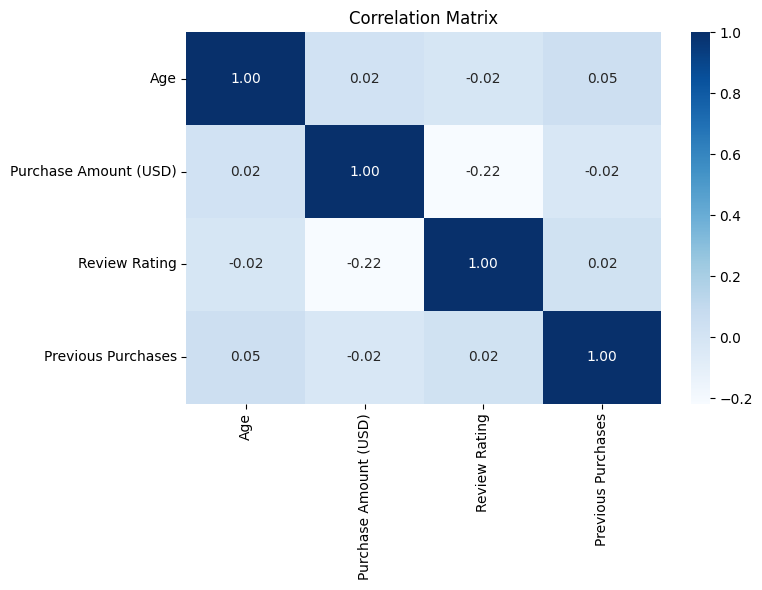

In [23]:
plt.figure(figsize=(8, 6))

numeric_columns = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']
correlation_matrix = custumer_data_copy[numeric_columns].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Correlation matrix insights

The numerical variables show only **very weak linear relationships**. Age, previous monetary history, and customer rating do not appear to have a strong direct linear connection with `Purchase Amount (USD)`.

In practical terms, this suggests that customer spending in this dataset is shaped more by categorical dimensions — such as product type, subscription status, purchase frequency, and shipping choices — than by simple linear numerical effects.


## 22. Summary report of the treatment and analysis

### Project context
This notebook presents a full workflow for inspecting, cleaning, standardizing, and exploring a customer shopping dataset. The purpose was to turn a messy dataset — affected by missing values, inconsistent labels, and repeated records — into a structure that supports clear analysis and portfolio-ready insights.

### What was addressed during cleaning
The main issues identified at the start were:
- missing values in `Purchase Amount (USD)`, `Review Rating`, `Previous Purchases`, and `Size`;
- **50 exact duplicate rows**;
- inconsistencies between `Item Purchased` and `Category`;
- a mix of cities and states in `Location`;
- duplicated meanings in `Frequency of Purchases`;
- semantic problems involving `Size`.

To improve the dataset:
- missing monetary values were imputed with hierarchical median-by-group strategies;
- `Review Rating` was kept as-is, while an indicator variable was added to distinguish reviewed and non-reviewed cases;
- `Size` was recoded as `Not Applicable` where clothing-style sizes were not meaningful;
- `Category` was realigned with `Item Purchased`;
- `Location` was standardized to the state level;
- purchase-frequency labels were harmonized;
- exact duplicate rows were removed.

### Main findings from the analysis
The final exploratory analysis highlighted a few clear patterns:
- **`Clothing`** is the most common category, but **`Electronics`** generates the highest purchase values;
- **subscribers spend more** than non-subscribers on average;
- more frequent buyers, especially **monthly** and **weekly** customers, tend to generate higher-value purchases;
- **`Electronics`** receives the lowest average ratings among the main product groups;
- numerical variables show **weak linear correlations**, suggesting that spending is better explained by customer and transaction categories than by simple numerical relationships.

### Final considerations
Overall, the project shows how much analytical value comes from careful data preparation. By cleaning the dataset and clarifying inconsistencies, it became possible to produce more credible visualizations and more useful business interpretations. The remaining issue involving `Fall` and `Autumn` is relatively minor, but it is worth correcting in a future version to make the seasonal analysis fully consistent.
